In [1]:
import numpy as np
import matplotlib.pyplot as plt

import genbart as gb

In [2]:
conf_color = '#227018'
fill_color = '#44f02e'

plt.style.use("bart_style.mplstyle")

In [3]:
def _predict_tree_row_from_st(x, st):
    node = 0
    while st.left[node] != -1:
        if x[st.variable[node]] <= st.value[node]:
            node = st.left[node]
        else:
            node = st.right[node]
    return st.mu[node]

def _predict_forest_matrix_from_saved_draw(draw, X):
    X = np.asarray(X)
    out = np.zeros(X.shape[0], dtype=float)
    for st in draw:
        for i in range(X.shape[0]):
            out[i] += _predict_tree_row_from_st(X[i], st)
    return out

def debug_packed_vs_manual(model, Xcheck):
    Xcheck = np.asarray(Xcheck)
    packed = model.packed_forest.draw_sums_matrix(Xcheck)

    k = len(model._debug_saved_draws)
    manual = np.zeros((k, Xcheck.shape[0]), dtype=float)
    for d in range(k):
        manual[d] = _predict_forest_matrix_from_saved_draw(
            model._debug_saved_draws[d], Xcheck
        )

    packed_k = packed[:k]

    print("max abs diff packed vs manual:", np.max(np.abs(packed_k - manual)))
    print("mean abs diff packed vs manual:", np.mean(np.abs(packed_k - manual)))

    print("packed draw std, first 10 x:", np.std(packed_k, axis=0)[:10])
    print("manual draw std, first 10 x:", np.std(manual, axis=0)[:10])

#  One Dimensional Example

In [4]:
def example_f(x: np.array):
    return np.sin(2*x) + np.cos(5*x) + 0.2*(x - 5.0)**2

In [5]:
m = [10, 100, 200]
n_samples = 300
x = np.linspace(1e-16, 10, n_samples)
y = example_f(x)
y_noise = example_f(x) + 0.5*np.random.randn(n_samples)

In [6]:
model_test = gb.RegBart(m=10, n_burn=200, n_samples=1000)
trace_py, splits_py = model_test.sse_trace_fixed_sigma(x, y_noise, n_iters=50)
print(trace_py, splits_py)

iter=  0 sse=10.17024899 rmse=0.18412178 splits=4
iter=  1 sse=7.96457441 rmse=0.16293735 splits=7
iter=  2 sse=7.98608122 rmse=0.16315720 splits=9
iter=  3 sse=6.81693503 rmse=0.15074189 splits=9
iter=  4 sse=6.17201379 rmse=0.14343423 splits=9
iter=  5 sse=6.08386865 rmse=0.14240633 splits=10
iter=  6 sse=6.00294213 rmse=0.14145603 splits=11
iter=  7 sse=5.37878762 rmse=0.13390031 splits=13
iter=  8 sse=5.37821822 rmse=0.13389322 splits=13
iter=  9 sse=4.73557350 rmse=0.12563934 splits=15
iter= 10 sse=4.63094969 rmse=0.12424371 splits=19
iter= 11 sse=5.00903107 rmse=0.12921598 splits=20
iter= 12 sse=3.90748536 rmse=0.11412691 splits=21
iter= 13 sse=3.40491187 rmse=0.10653500 splits=20
iter= 14 sse=3.11235853 rmse=0.10185543 splits=21
iter= 15 sse=3.07644026 rmse=0.10126599 splits=20
iter= 16 sse=3.02919133 rmse=0.10048534 splits=18
iter= 17 sse=2.86584414 rmse=0.09773850 splits=19
iter= 18 sse=3.09395292 rmse=0.10155381 splits=19
iter= 19 sse=2.55884213 rmse=0.09235515 splits=19
iter

In [ ]:
model_10 = gb.RegBart(m=10, n_burn=200, n_samples=1000).fit(x, y_noise)

before sigma draw: sse= 7.427737873848711 sigma2_current= 0.037553978705150606
before sigma draw: sse= 5.252673189594862 sigma2_current= 0.023517607165509023
before sigma draw: sse= 4.946155223096849 sigma2_current= 0.016381371460974768
before sigma draw: sse= 4.441111435927741 sigma2_current= 0.016803790457468614
before sigma draw: sse= 4.161135413044104 sigma2_current= 0.01583206795661043
before sigma draw: sse= 4.006657652676875 sigma2_current= 0.01379722355619956
before sigma draw: sse= 3.1729388716199294 sigma2_current= 0.012274176175667157
before sigma draw: sse= 2.675442385046777 sigma2_current= 0.012528944697905529
before sigma draw: sse= 2.5554564748696826 sigma2_current= 0.008034244848966936
before sigma draw: sse= 2.4960450735974877 sigma2_current= 0.008308798713073731
before sigma draw: sse= 2.396813329980561 sigma2_current= 0.007746787018031628
before sigma draw: sse= 2.2829691529814977 sigma2_current= 0.007594109585399912
before sigma draw: sse= 2.2317927836003735 sigma2_

In [7]:
model_100 = gb.RegBart(m=100, n_burn=200, n_samples=500).fit(x, y_noise)

In [8]:
model_200 = gb.RegBart(m=200, n_burn=200, n_samples=500).fit(x, y_noise)

In [9]:
pred_x = np.linspace(2e-16, 10, 1000)
pred_y = example_f(pred_x)
y_bart = []

y_bart.append(model_10.predict(pred_x))
y_bart.append(model_100.predict(pred_x))
y_bart.append(model_200.predict(pred_x))

In [10]:
mse = []
cov_probs = []
for i in range(len(y_bart)):
    mse.append(np.mean((pred_y - y_bart[i]["prediction"])**2))
    cov_probs.append(np.mean([(y_bart[i]["conf_int_low"][j] < pred_y[j] < y_bart[i]["conf_int_high"][j]) for j in range(200)]))

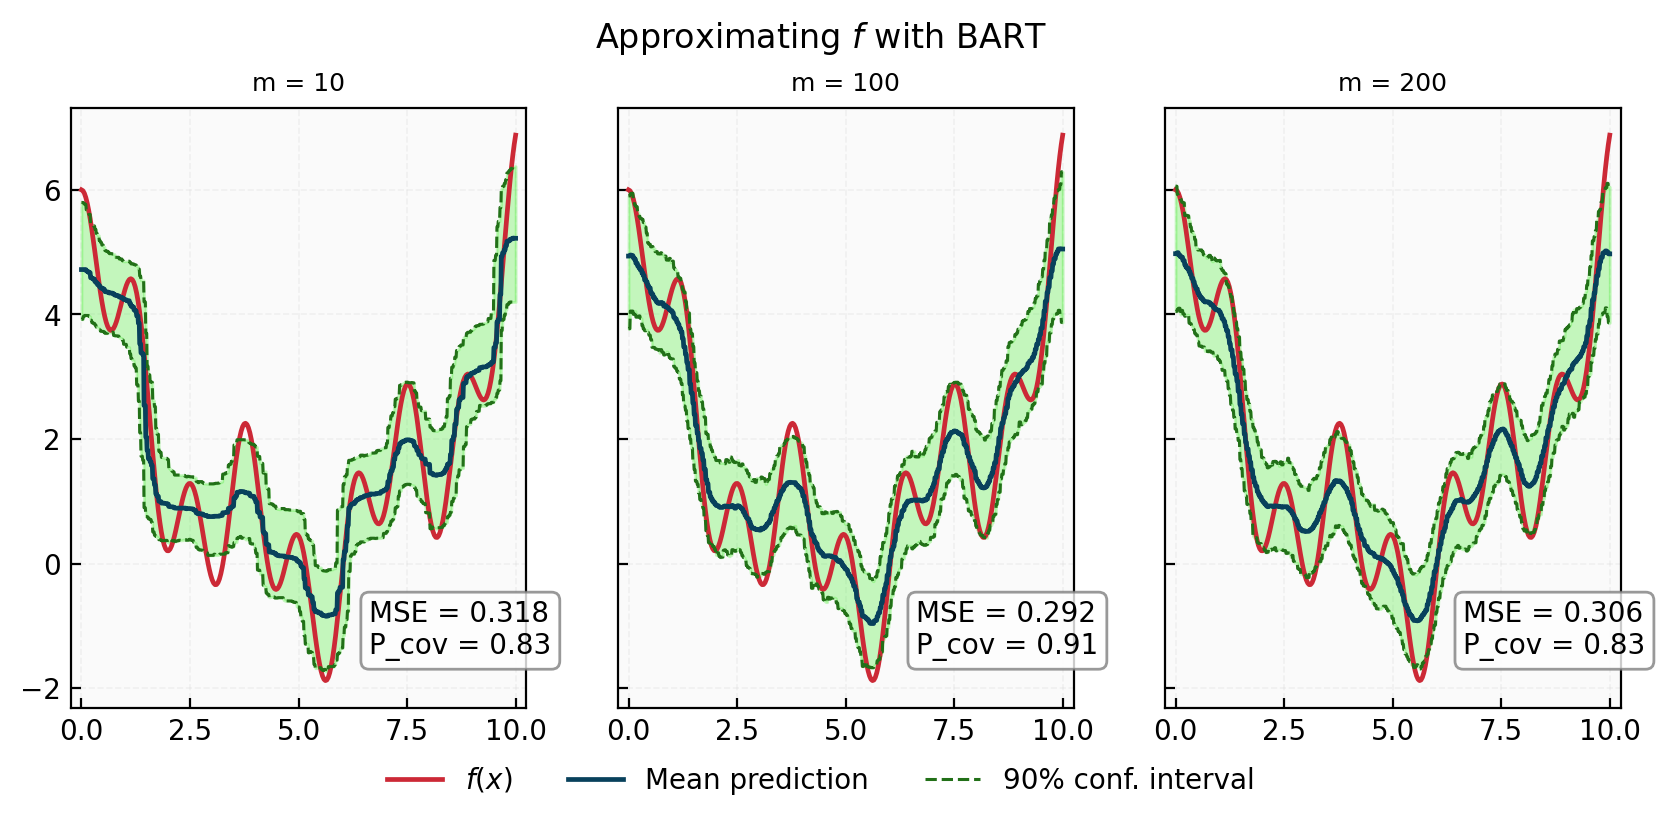

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, dpi=200)
for i in range(len(y_bart)):
    axes[i].plot(x, y, label=r"$f(x)$")
    axes[i].plot(pred_x, y_bart[i]["prediction"], label="Mean prediction", zorder=10)
    axes[i].plot(pred_x, y_bart[i]["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
    axes[i].plot(pred_x, y_bart[i]["conf_int_high"], ls='--', lw=1.1, c=conf_color)
    axes[i].fill_between(pred_x, y_bart[i]["conf_int_low"], y_bart[i]["conf_int_high"], color=fill_color, alpha=0.3)
    axes[i].set_title(f"m = {m[i]}", fontsize=9)
    axes[i].text(0.655, 0.09,
                 f"MSE = {mse[i]:.3f}\nP_cov = {cov_probs[i]:.2f}",
                 transform=axes[i].transAxes,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3)

fig.suptitle("Approximating $f$ with BART", fontsize=12)

plt.subplots_adjust(bottom=0.12)
plt.subplots_adjust(top=0.87)
plt.show()

# Multidimensional Example

In [11]:
def example_2d_f(x, y):
    return np.sin(0.05*x*y) + 0.3*(np.cos(x) + np.cos(y)) - 0.05*x*y

In [12]:
x = np.linspace(-2*np.pi, 2*np.pi, 100)
y = np.linspace(-2*np.pi, 2*np.pi, 100)
X, Y = np.meshgrid(x, y)

true_Z = example_2d_f(X, Y)
Z = true_Z + 0.25*np.random.randn(len(x), len(y))


In [13]:
model_2d = gb.RegBart(m=100).fit(np.column_stack((X.ravel(), Y.ravel())), Z.ravel())

In [14]:
x_pred = np.linspace(-2*np.pi, 2*np.pi, 20)
X_pred, Y_pred = np.meshgrid(x_pred, x_pred)
pred_points = np.column_stack((X_pred.ravel(), Y_pred.ravel()))
preds_2d = model_2d.predict(pred_points)

slice_mask = np.isclose(Y.ravel(), min(y))
preds_slice = model_2d.predict(np.column_stack((X.ravel(), Y.ravel()))[slice_mask, :])

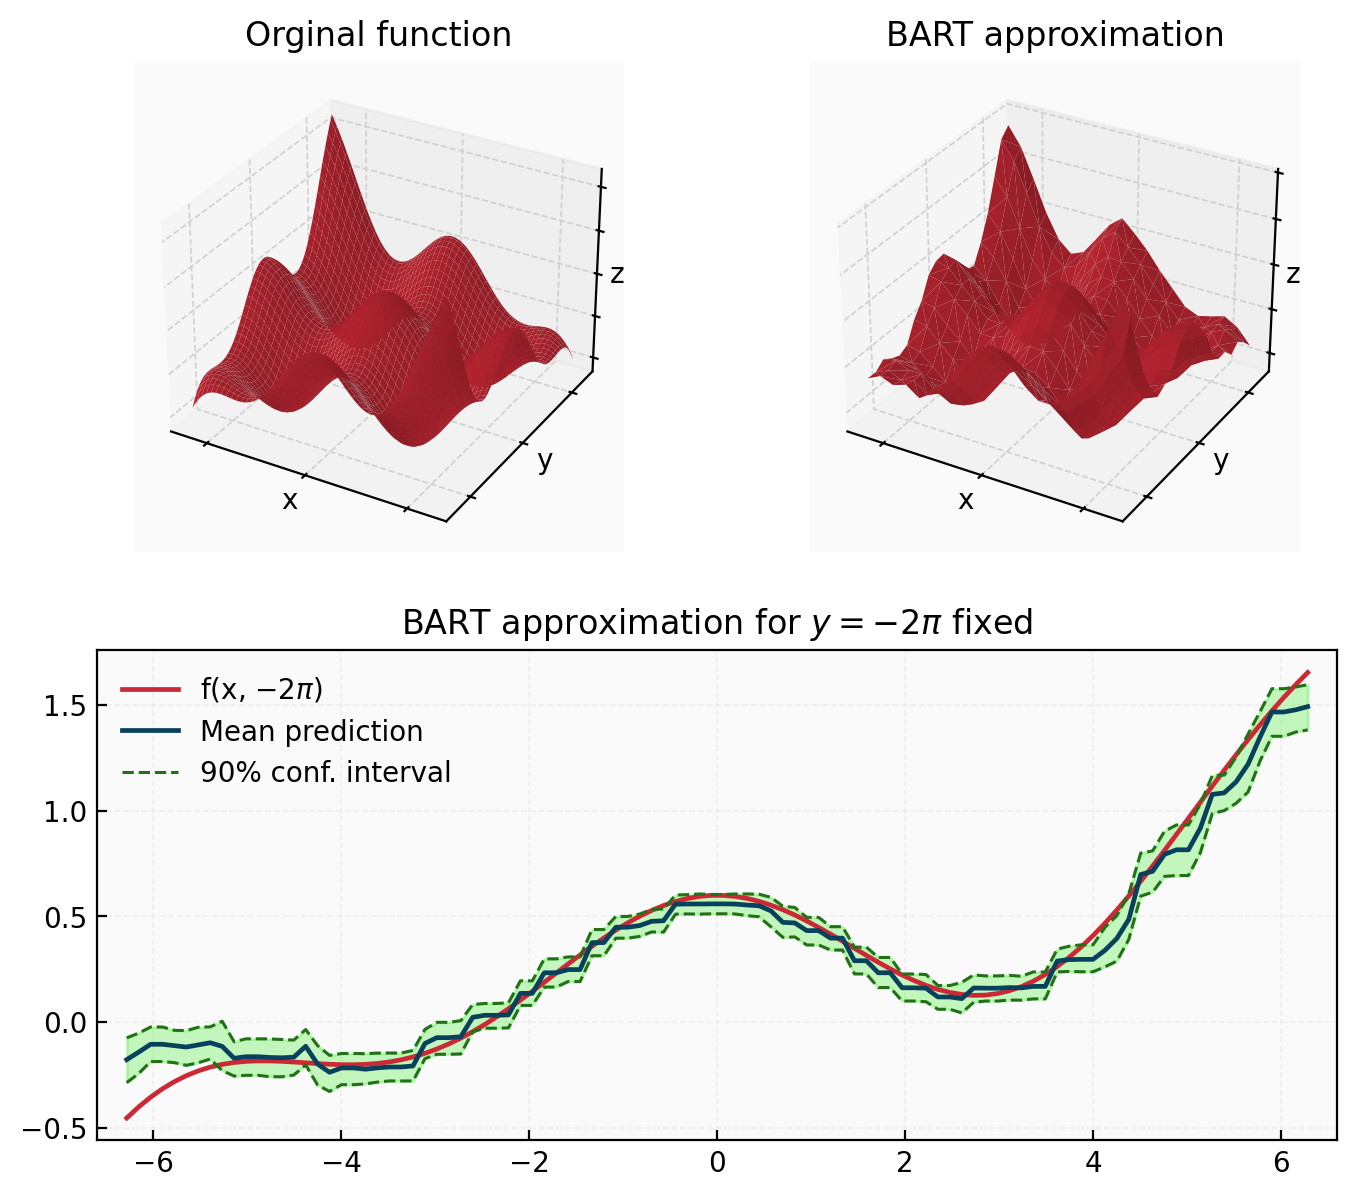

In [15]:
fig = plt.figure(figsize=(8, 7), dpi=200)
gs = fig.add_gridspec(2, 2)

ax_original = fig.add_subplot(gs[0, 0], projection="3d")
ax_original.plot_surface(X, Y, true_Z)
ax_original.set_title("Orginal function")
ax_original.set_xlabel("")
ax_original.text2D(0.3, 0.09, "x", transform=ax_original.transAxes)
ax_original.set_xticklabels([])
ax_original.set_ylabel("")
ax_original.text2D(0.82, 0.17, "y", transform=ax_original.transAxes)
ax_original.set_yticklabels([])
ax_original.set_zlabel("")
ax_original.text2D(0.97, 0.55, "z", transform=ax_original.transAxes)
ax_original.set_zticklabels([])

ax_bart = fig.add_subplot(gs[0, 1], projection="3d")
ax_bart.plot_trisurf(X_pred.ravel(), Y_pred.ravel(), preds_2d["prediction"])
ax_bart.set_title("BART approximation")
ax_bart.set_xlabel("")
ax_bart.text2D(0.3, 0.09, "x", transform=ax_bart.transAxes)
ax_bart.set_xticklabels([])
ax_bart.set_ylabel("")
ax_bart.text2D(0.82, 0.17, "y", transform=ax_bart.transAxes)
ax_bart.set_yticklabels([])
ax_bart.set_zlabel("")
ax_bart.text2D(0.97, 0.55, "z", transform=ax_bart.transAxes)
ax_bart.set_zticklabels([])

ax_slice = fig.add_subplot(gs[1, :])
ax_slice.plot(x, example_2d_f(x, min(y)), label=r"f(x, $-2\pi$)")
ax_slice.plot(x, preds_slice["prediction"], label="Mean prediction")
ax_slice.plot(x, preds_slice["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
ax_slice.plot(x, preds_slice["conf_int_high"], ls='--', lw=1.1, c=conf_color)
ax_slice.fill_between(x, preds_slice["conf_int_low"], preds_slice["conf_int_high"], color=fill_color, alpha=0.3)
ax_slice.set_title(r"BART approximation for $y=-2\pi$ fixed")
ax_slice.legend()

plt.show()

# Friedman Function Example

In [21]:
def friedman(x: np.ndarray):
    return (10.0 * np.sin(np.pi*x[:, 0]*x[:, 1])
            + 20.0 * (x[:, 2]-0.5)**2
            + 10.0 * x[:, 3]
            + 5.0 * x[:, 4])

## Variable selection

In [22]:
n_samples = 500
x = np.random.rand(n_samples, 50)
true_y = friedman(x)
y = true_y + 0.5*np.random.randn(n_samples)

vs_model10 = gb.RegBart(m=10, n_burn=200, n_samples=5000).fit(x, y)

In [24]:
vs_model20 = gb.RegBart(m=20, n_burn=200, n_samples=5000).fit(x, y)

In [25]:
vs_model50 = gb.RegBart(m=50, n_burn=200, n_samples=5000).fit(x, y)

In [26]:
variable_importance_10 = vs_model10.variable_importance()
variable_importance_20 = vs_model20.variable_importance()
variable_importance_50 = vs_model50.variable_importance()

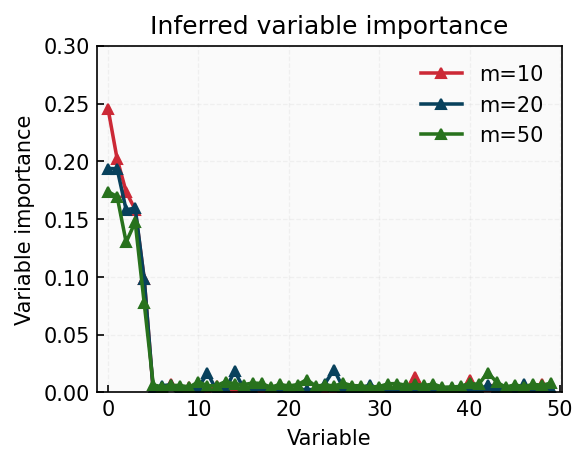

In [29]:
fig, ax = plt.subplots(figsize=(4,3), dpi=150)

ax.plot(variable_importance_10, marker='^', label="m=10")
ax.plot(variable_importance_20, marker='^', label="m=20")
ax.plot(variable_importance_50, marker='^', label="m=50")

ax.set_ylim(0.0, 0.3)
ax.set_title("Inferred variable importance")
ax.set_xlabel("Variable")
ax.set_ylabel("Variable importance")

plt.legend()
plt.show()

## Marginalizations

In [16]:
n_samples = 100
x = np.random.rand(n_samples, 2)
true_y = x[:, 0] + x[:, 1]**2
y = true_y + 0.5*np.random.randn(n_samples)

In [17]:
model_marg = gb.RegBart(m=200, n_samples=500).fit(x, y)

In [18]:
marg_x1 = model_marg.marginalize(0, np.linspace(0, 1, 10))

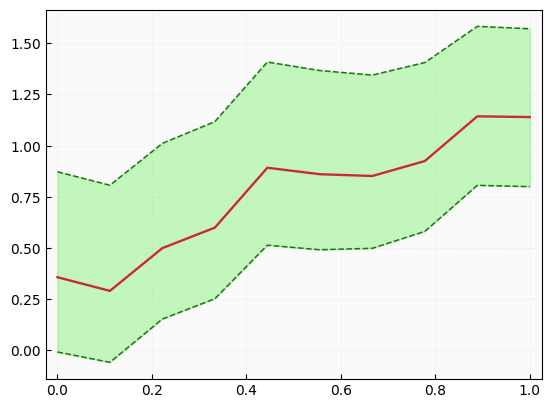

In [19]:
plt.plot(np.linspace(0, 1, 10), marg_x1["prediction"])
plt.plot(np.linspace(0, 1, 10), marg_x1["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
plt.plot(np.linspace(0, 1, 10), marg_x1["conf_int_high"], ls='--', lw=1.1, c=conf_color)
plt.fill_between(np.linspace(0, 1, 10), marg_x1["conf_int_low"], marg_x1["conf_int_high"], color=fill_color, alpha=0.3)
plt.show()